In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans 
import pandas as pd
from sklearn.metrics import silhouette_samples, silhouette_score
from tqdm import tqdm


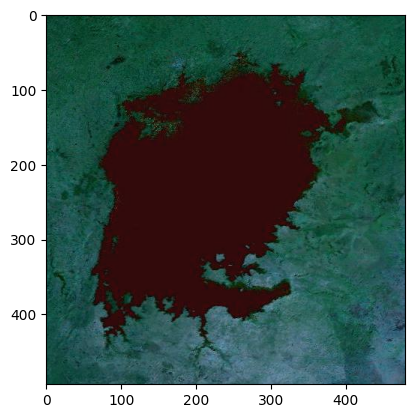

In [119]:
image_path = 'C:\\Users\\Dell\\Desktop\\Files\\7th_sem\\DM\\Kmeans\\lake.jpg'
image2 = cv2.imread(image_path)
plt.imshow(image2)



In [120]:
print(image2.shape)


(494, 480, 3)


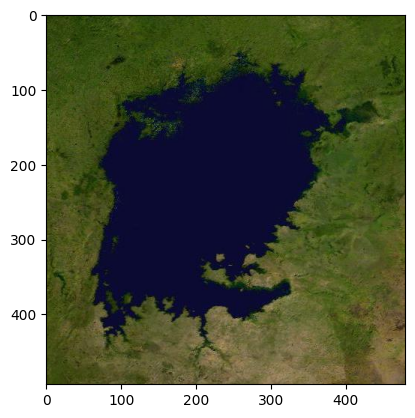

In [138]:
image = cv2.imread(image_path)
image2 = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
plt.imshow(image2)

In [139]:
img_reshaped = image2.reshape(-1,3)


In [140]:
img_reshaped.shape

(237120, 3)

In [141]:
no_clusters = 3

In [142]:

kmeans = KMeans(n_clusters = no_clusters, random_state= 42)


In [143]:
kmeans.fit(img_reshaped)

KMeans(n_clusters=3, random_state=42)

In [144]:
labels = kmeans.labels_

In [145]:
cluster_centers = kmeans.cluster_centers_
cluster_centers

array([[ 64.51998771,  79.5696881 ,  22.88997948],
       [ 11.63879685,  12.98480534,  45.78051874],
       [107.20555544, 103.4235263 ,  56.56403796]])

In [146]:
np.rint(cluster_centers)

array([[ 65.,  80.,  23.],
       [ 12.,  13.,  46.],
       [107., 103.,  57.]])

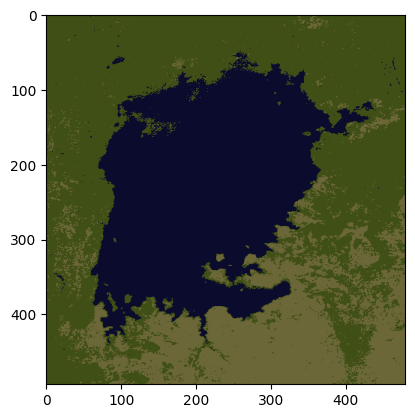

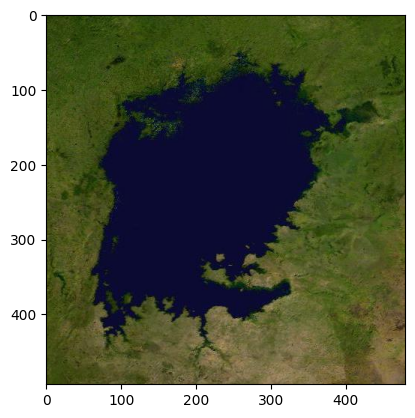

In [148]:
clustered_image = cluster_centers[labels].astype(np.uint8).reshape(image2.shape)
plt.imshow(clustered_image)
plt.show()
plt.imshow(image2)
plt.show()

In [165]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(image2.flatten(), clustered_image.flatten())
mse


54.23811431623932

In [164]:
def calculate_mse(image2, clustered_image):
    # Get the dimensions of the images
    m = len(image2)
    n = len(image2[0])
    channels = len(image2[0][0])
    
    # Initialize the MSE
    mse = 0.0
    
    # Calculate the sum of squared differences
    for i in range(m):
        for j in range(n):
            for k in range(channels):
                    mse += (float(image2[i][j][k]) - float(clustered_image[i][j][k])) ** 2
            
    # Calculate the mean
    mse /= (m * n*channels)
    
    return mse


mse = calculate_mse(image2, clustered_image)
print("Mean Squared Error:", mse)




Mean Squared Error: 119.12088534637877


In [ ]:
def calculate_mse(original_image, segmented_image):
    # Check if images are 3D (color) or 2D (grayscale)
    if len(original_image[0][0]) == 3:
        # Color images
        m = len(original_image)
        n = len(original_image[0])
        channels = len(original_image[0][0])
        
        mse = 0.0
        
        for i in range(m):
            for j in range(n):
                for k in range(channels):
                    mse += (float(original_image[i][j][k]) - float(segmented_image[i][j][k])) ** 2
        
        mse /= (m * n * channels)
    else:
        # Grayscale images
        m = len(original_image)
        n = len(original_image[0])
        
        mse = 0.0
        
        for i in range(m):
            for j in range(n):
                mse += (float(original_image[i][j]) - float(segmented_image[i][j])) ** 2
        
        mse /= (m * n)
    
    return mse